# Notebook 05 - Machine Learning Model Development

This notebook trains Machine Learning models to classify user intents.

Model:
- Support Vector Machine (SVM)

In [2]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [4]:
df = pd.read_csv("../data/intents_clean.csv")

df.head()

,text,intent,response
0,catch later,goodbye,Response for goodbye.
1,hi,greeting,Response for greeting.
2,good morning,greeting,Response for greeting.
3,cost redmi note 14,price_query,Response for price_query.
4,availability galaxy s24,availability,Response for availability.


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   text      1000 non-null   object
 1   intent    1000 non-null   object
 2   response  1000 non-null   object
dtypes: object(3)
memory usage: 23.6+ KB


In [6]:
df.isnull().sum()

text        0
intent      0
response    0
dtype: int64

In [7]:
df["intent"].value_counts()

intent
accessory_search    114
price_query         107
payment             106
comparison          101
goodbye             100
greeting             99
recommendation       96
thanks               95
phone_search         94
availability         88
Name: count, dtype: int64

In [8]:
X = df["text"]

y = df["intent"]

In [9]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(X)

print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (1000, 76)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 800
Testing Samples  : 200


In [11]:
svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adj

In [12]:
y_pred = svm_model.predict(X_test)

y_pred[:10]

array(['price_query', 'greeting', 'thanks', 'recommendation',
       'recommendation', 'price_query', 'goodbye', 'phone_search',
       'thanks', 'price_query'], dtype=object)

In [13]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 97.5 %


In [14]:
print(classification_report(y_test, y_pred))

                  precision    recall  f1-score   support

accessory_search       1.00      1.00      1.00        23
    availability       0.88      0.83      0.86        18
      comparison       0.86      0.90      0.88        20
         goodbye       1.00      1.00      1.00        20
        greeting       1.00      1.00      1.00        20
         payment       1.00      1.00      1.00        21
    phone_search       1.00      1.00      1.00        19
     price_query       1.00      1.00      1.00        21
  recommendation       1.00      1.00      1.00        19
          thanks       1.00      1.00      1.00        19

        accuracy                           0.97       200
       macro avg       0.97      0.97      0.97       200
    weighted avg       0.98      0.97      0.97       200



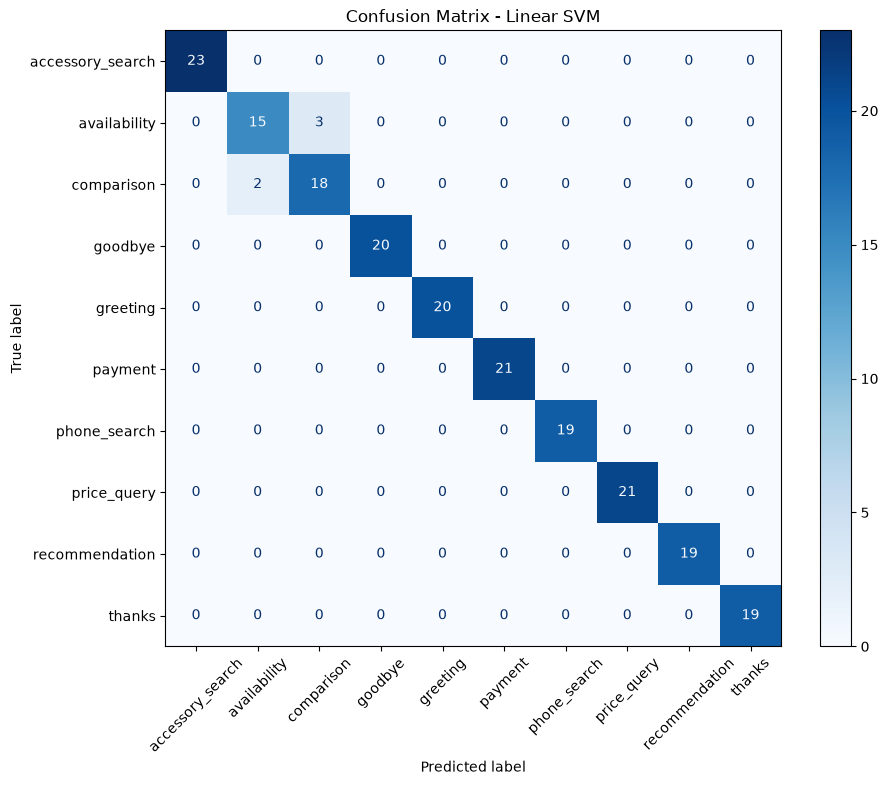

In [15]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=svm_model.classes_
)

disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - Linear SVM")

plt.show()

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[23  0  0  0  0  0  0  0  0  0]
 [ 0 15  3  0  0  0  0  0  0  0]
 [ 0  2 18  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0]
 [ 0  0  0  0  0 21  0  0  0  0]
 [ 0  0  0  0  0  0 19  0  0  0]
 [ 0  0  0  0  0  0  0 21  0  0]
 [ 0  0  0  0  0  0  0  0 19  0]
 [ 0  0  0  0  0  0  0  0  0 19]]


In [39]:
new_sentences = [

    "Do you have Samsung phones?",

    "I need an iPhone charger",

    "My phone screen is broken",

    "How much is Samsung A56?",

    "Can you replace my battery?",

    "What is your warranty period?",

    "Do you have AirPods?",

    "I need a phone case"

]

new_vectors = vectorizer.transform(new_sentences)

predictions = svm_model.predict(new_vectors)

for sentence, prediction in zip(new_sentences, predictions):

    print(sentence)

    print("Predicted Intent :", prediction)

    print("-"*50)

Do you have Samsung phones?
Predicted Intent : phone_search
--------------------------------------------------
I need an iPhone charger
Predicted Intent : accessory_search
--------------------------------------------------
My phone screen is broken
Predicted Intent : accessory_search
--------------------------------------------------
How much is Samsung A56?
Predicted Intent : price_query
--------------------------------------------------
Can you replace my battery?
Predicted Intent : recommendation
--------------------------------------------------
What is your warranty period?
Predicted Intent : availability
--------------------------------------------------
Do you have AirPods?
Predicted Intent : accessory_search
--------------------------------------------------
I need a phone case
Predicted Intent : accessory_search
--------------------------------------------------


In [40]:
feature_names = vectorizer.get_feature_names_out()

for i, intent in enumerate(svm_model.classes_):

    print("\nIntent :", intent)

    top = svm_model.coef_[i].argsort()[-10:]

    print(feature_names[top])


Intent : accessory_search
['need' 'screen' 'protector' 'cable' 'usbc' 'bank' 'power' 'charger'
 'airpods' 'case']

Intent : availability
['14' 'reno' 'iphone' '15' 'v50' '13' 'availability' 'available' 'stock'
 'buy']

Intent : comparison
['iphone' 'reno' '13' 'v50' 's24' 'galaxy' '14' 'better' 'difference'
 'compare']

Intent : goodbye
['better' 'difference' 'latest' 'later' 'catch' 'day' 'nice' 'bye' 'see'
 'goodbye']

Intent : greeting
['reno' 'better' 'difference' 'latest' 'morning' 'evening' 'good' 'hello'
 'hi' 'hey']

Intent : payment
['latest' 'method' 'online' 'accepted' 'card' 'cash' 'pay' 'use' 'visa'
 'payment']

Intent : phone_search
['latest' 'phone' 'mobile' 'vivo' 'oneplus' 'oppo' 'samsung' 'xiaomi'
 'apple' 'realme']

Intent : price_query
['note' 'redmi' 'iphone' '15' 'reno' '14' 'tell' 'cost' 'much' 'price']

Intent : recommendation
['difference' 'tell' 'mobile' 'gaming' 'battery' 'camera' 'phone'
 'student' 'recommend' 'best']

Intent : thanks
['cost' 'stock' 'avail

In [41]:
joblib.dump(
    svm_model,
    "../models/svm_model.pkl"
)

joblib.dump(
    vectorizer,
    "../models/tfidf_vectorizer.pkl"
)

print("Model Saved Successfully.")

Model Saved Successfully.


In [42]:
loaded_model = joblib.load("../models/svm_model.pkl")

loaded_vectorizer = joblib.load("../models/tfidf_vectorizer.pkl")

In [43]:
text = [

    "Do you have Redmi phones?"

]

text_vector = loaded_vectorizer.transform(text)

prediction = loaded_model.predict(text_vector)

print("Prediction:", prediction[0])

Prediction: availability
